#### **Accuracy** - Modellərin Qiymətləndirilməsi (Ehtimal əsaslı)  - Probabilistic Evaluation of Model, Calibration Curve -  Ehtimal-ların (Probability) intervallara (bin) bölünməsi

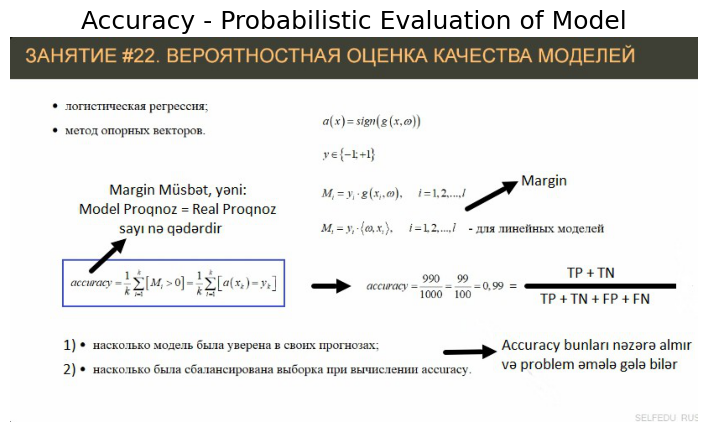

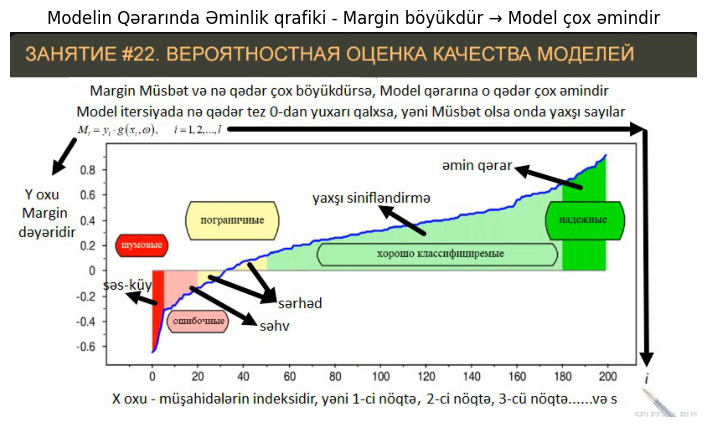

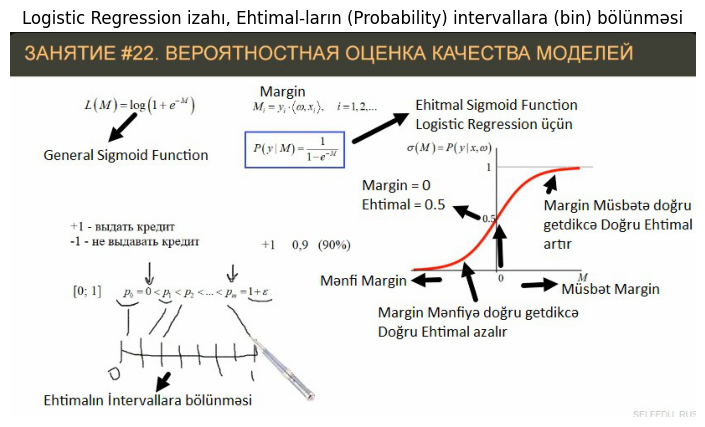

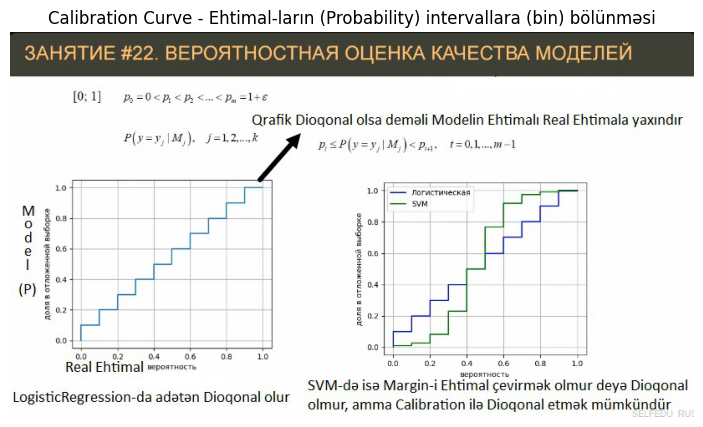

In [7]:
from PIL import Image

# Fayl yolunun əsas hissəsi
base_path = r'C:\Users\dell\Desktop\Selfedu\Pictures\ML_22_'

# Şəkilləri saxlayacağımız siyahı
image_list = []

# 1-dən 5-ə qədər olan şəkilləri dövr ilə açırıq
for i in range(1, 5):  # 1-dən 5-ə qədər
    full_path = f'{base_path}{i}.jpg'  # Fayl yolunu dinamik olaraq yaradırıq
    img = Image.open(full_path)
    image_list.append(img)  # Şəkili siyahıya əlavə edirik

# Nəticə: images siyahısında bütün yüklənmiş şəkillər olacaq

import matplotlib.pyplot as plt

# Şəkilləri göstərin
for i, image in enumerate(image_list):
    if i == 100:
        plt.figure(figsize=(8.8, 4))          
    else:     
        plt.figure(figsize=(25, 5))  # Şəkilin ölçüsü    
        
    if i < 1:
        plt.title("""Accuracy - Probabilistic Evaluation of Model""", size='18')
    elif i < 2:
        plt.title("""Modelin Qərarında Əminlik qrafiki - Margin böyükdür → Model çox əmindir""", size='12')
    elif i < 3:
        plt.title("""Logistic Regression izahı, Ehtimal-ların (Probability) intervallara (bin) bölünməsi""", size='12')
    elif i < 4:
        plt.title("""Calibration Curve - Ehtimal-ların (Probability) intervallara (bin) bölünməsi""", size='12')         
    
    plt.imshow(image)
    plt.axis('off')  # Oxları gizlətmək üçün
    plt.show()

### Margin-in ($\cdot y$-siz) mənası

> **Margin ($\cdot y$-siz) — Bir nöqtənin iki sinfi ayıran xətdən nə qədər uzaqda olduğunu və xəttin hansı tərəfində yerləşdiyini göstərir. Yəni $w^T x + b$  təkcə tərəfi yox, həm də uzaqlıqla bağlı məlumat verir, amma tam uzaqlıq deyil. Hələki  $y$-ə çarpmadığımıza görə bilmirk Model düz qərar verib ya yox**

<br>

#### 🔹 **1. Nəyi göstərir?**

> **İşarə → hansı tərəfdədir**

> **Modul (böyüklük) → xəttdən nə qədər uzaqdır (amma scaled şəkildə)**

<br>

#### 🔹 **2. Amma bu real məsafə deyil ❗**

Çünki $w$-nin ölçüsündən asılıdır.

👉 Həqiqi (perpendicular) məsafə belədir:

$d = \frac{|w^T x + b|}{|w|}$

<br>

#### 🔹 **3. Intuitiv izah:**

* $w^T x + b$ → “uzaqlıq + istiqamət (scale olunmuş)”
* $||w||$-ə böləndə → **real məsafə alınır**

<br>

#### **🔚 Qısa yekun:**

- ✔ $w^T x + b$ → **tərəf + uzaqlıq (amma dəqiq yox)**
- ✔ $\frac{|w^T x + b|}{||w||}$ → **real məsafə**
- $∥w∥$-ə **ona görə bölürük ki, çünki məsafə = proyeksiya / normal vektorun uzunluğu. $w$ nə qədər böyükdürsə, $w^T x + b$ da süni böyüyür → buna görə normaya bölüb normallaşdırırıq.**
- 👉 $||w||$ **isə minimallaşdırılır ki, Margin (yəni xəttdən minimum məsafə) maksimum olsun**.

 <br>

#### 🔹 **Qərar xətti:**

$$
w^T x + b = 0
$$

<br>

#### 🔹 **İndi baxaq:**

* **$w^T x + b > 0$**
  → nöqtə xəttin **bir tərəfindədir**

* **$w^T x + b < 0$**
  → nöqtə xəttin **digər tərəfindədir**

<br>

#### 🔹 **Vacib nüans:**

Bu “hansı tərəf” olduğu **işarədən asılıdır**, amma:

* hansı tərəfin “+” və ya “−” olması → $w$ vektorunun istiqamətindən asılıdır

<br>

#### 🔹 **Intuitiv:**

- $w^T x + b$ sadəcə deyir:
-  👉 “sən xəttin hansı tərəfindəsən?”

<br>

#### **🔚 Yekun:**

- ✔ Müsbət → bir tərəf
- ✔ Mənfi → digər tərəf
- ✔ 0 → düz xəttin üstü


### Margin-in ($\cdot y$ ilə) mənası

> **Margin ($\cdot y$ ilə) — Modelin bir nöqtəni düzgün düzgün təsnif edib-etmədiyini və iki sinfi ayıran xətdən nə qədər uzaqda olduğunu göstərir. Yəni $ y(w^T x + b) $ düzgünlük məlumatını verir, böyüklüyü isə uzaqlıqla bağlıdır (amma hələ tam məsafə deyil). $y$-ə vurduğumuza görə artıq bilirik ki model düz qərar verib ya yox.**

<br>

#### 🔹 **Məntiq:**

**Tam olaraq söhbət bir nöqtədən gedir** 👍

> **Yəni biz hər dəfə bir data point, yəni bir nümunə - Özü ve Class-ı (bir ($x_i, y_i)$) götürürük və baxırıq:**

$$
y_i (w^T x_i + b)
$$

<br>

#### Model deyir:
$$
w^T x + b
$$
→ modelin **proqnozu (işarəsi)**

<br>

#### Real cavab:
$$
y
$$
→ **həqiqi label** ($**+1$** və ya $**-1$**)

<br>

#### ✅ **1. Model müsbət dedi, real da müsbətdir**

- $ w^T x + b > 0 $
- $ y = +1 $
-  → $ y(w^T x + b) > 0 $ → **doğru**

<br>

#### ❌ **2. Model müsbət dedi, real mənfidir**

- $ w^T x + b > 0 $
- $ y = -1 $
- → $ y(w^T x + b) < 0 $ → **səhv**

<br>

#### ❌ **3. Model mənfi dedi, real müsbətdir**

- $ w^T x + b < 0 $
- $ y = +1 $
- → $ y(w^T x + b) < 0 $ → **səhv**

<br>

#### ✅ **4. Model mənfi dedi, real da mənfidir**

- $ w^T x + b < 0 $
- $ y = -1 $
- → $ y(w^T x + b) > 0 $ → **doğru**

<br>

#### ⚠️ **5. Sərhəd halı (decision boundary)**

- $ w^T x + b = 0 $
-  → $ y(w^T x + b) = 0 $
-  → model **tam qərarsızdır** (sərhəddədir)

<br>

#### **🔚 Bir cümlə (tam versiya):**

> **Modelin dediyi işarə ilə real $y$-nin işarəsi eynidirsə → vuranda müsbət çıxır (doğru), fərqlidirsə → mənfi çıxır (səhv), $0$ olarsa → nöqtə sərhəddədir.**


### Accuracy 

> **Accuracy (dəqiqlik)** — **modelin düzgün təsnif etdiyi nümunələrin bütün nümunələrə nisbətidir. Yəni, modelin nə qədər “doğru” işlədiyini göstərir.**

> **Accuracy (dəqiqlik) maşın öyrənməsi və statistika sahəsində ən sadə performans ölçülərindən biridir. O, modelin düzgün proqnoz verdiyi halların ümumi hallara nisbətini göstərir.**

<br>

**Tərifi:**

$$
\text{Accuracy} = \frac{\text{Düzgün təsnif olunan nümunələrin sayı}}{\text{Ümumi nümunələrin sayı}}
$$

<br>

**Confuison Matrix**


|                   | **Model Positive**           | **Model Negative**            |
| ----------------- | ---------------------------- | ----------------------------- |
| **Real Positive** | <div style="text-align:center">**TP**                       | <div style="text-align:center">**FN** <br> **Type II Error** |
| **Real Negative** |  <div style="text-align:center">**FP** <br> **Type I Error** | <div style="text-align:center">**TN**                        |
    
<br>
    
**Simvolik düsturla:**

$$
\text{Accuracy} = \frac{TP + TN}{TP + TN + FP + FN}
$$

Burada:

* $TP$ = True Positive (doğru müsbət)
* $TN$ = True Negative (doğru mənfi)
* $FP$ = False Positive (səhv müsbət)
* $FN$ = False Negative (səhv mənfi)


**Misal:**
100 nümunədən 90-ını düzgün proqnoz etsək, accuracy belə hesablanır:
$$
\text{Accuracy} = \frac{90}{100} = 0.9 = 90%
$$


Qısa desək: **Accuracy = Düzgünlərin faizi**.

    
    
<br>

#### **Diqqqət ediləsi nüans**
> **Qısa desək, accuracy modelin ümumi düzgünlüyünü ölçür, amma Balanssız (məsələn, 95% mənfi, 5% müsbət olan) datasetlərdə yanıltıcı ola bilər.** 
       


### Accuracy niyə problemlidir? - nəyi nəzərə almır?

**Accuracy sadəcə neçə düzgün proqnoz etdiyini ölçür:**

$$
Accuracy = \frac{TP + TN}{TP + TN + FP + FN}
$$

Yəni:

> * ❌ **Modelin özünə nə qədər əmin olduğunu (confidence/probability) nəzərə almır**
> * ❌ **Datasetin balanslı olub-olmadığını nəzərə almır**

<br>

#### **Niyə problem yaradır?**

**1. Confidence məsələsi**

* **Model 0.51 ehtimalla desin “1”**
* **Başqa model 0.99 ehtimalla desin “1”**

➡️ **Accuracy üçün fərqi yoxdur — ikisi də düzdür = 1 xal**

<br>

**2. Balanssız data (çox vacib!)**
Məsələn:

* **100 nəfərdən 95-i “negative”, 5-i “positive”**

**odel hamıya “negative” desə:**

*  **Accuracy = 95%** 😄
* **Amma model heç nə öyrənməyib** 😐

<br>

#### **Ona görə nə istifadə olunur?**

**Bu problemləri həll etmək üçün:**

* **Precision**
* **Recall**
* **F1-score**
* **ROC-AUC**

**istifadə olunur.**



#### Modelin ehtimal (probability) proqnozlarının düzgünlüyünü yoxlayan kalibrasiya qrafikləri
- #### **Calibration curve və ya Reliability diagram**

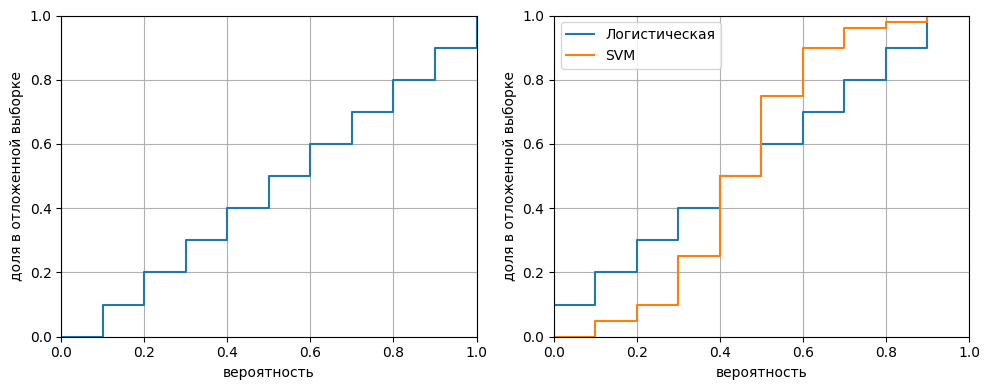

In [15]:
import numpy as np
import matplotlib.pyplot as plt

# --- Data (təxmini şəkildə eyni görünüş üçün) ---
# Sol qrafik (kalibrasiya kimi düz xəttə yaxın step)
p = np.linspace(0, 1, 11)
y = p  # ideal kalibrasiya

# Sağ qrafik (Logistic vs SVM fərqli step-lər)
p2 = np.linspace(0, 1, 11)

logistic = np.array([0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0, 1.0])
svm = np.array([0.0, 0.05, 0.1, 0.25, 0.5, 0.75, 0.9, 0.96, 0.98, 1.0, 1.0])

# --- Plot ---
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Sol qrafik
axes[0].step(p, y, where='post')
axes[0].set_xlabel("вероятность")
axes[0].set_ylabel("доля в отложенной выборке")
axes[0].set_xlim(0, 1)
axes[0].set_ylim(0, 1)
axes[0].grid(True)

# Sağ qrafik
axes[1].step(p2, logistic, where='post', label='Логистическая')
axes[1].step(p2, svm, where='post', label='SVM')
axes[1].set_xlabel("вероятность")
axes[1].set_ylabel("доля в отложенной выборке")
axes[1].set_xlim(0, 1)
axes[1].set_ylim(0, 1)
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

> Bu qrafiklər **modelin ehtimal (probability) proqnozlarının düzgünlüyünü yoxlayan kalibrasiya qrafikləridir**. Adı adətən **Calibration curve / Reliability diagram** olur.

Şəkildə yazılan formulalar da bunu göstərir:

* Ehtimal intervala bölünür:
  $$
  p_i \le P(y = y_j \mid M_j) < p_{i+1}
  $$
> - **Yəni modelin verdiyi ehtimallar interval (bin)-lara bölünür və hər intervalda real nəticə ilə müqayisə edilir**.

<br>

#### **Bu qrafik nəyi göstərir?**

Oxlar:

* **X oxu (вероятность)** → **Modelin dediyi ehtimal (prediction probability)**
* **Y oxu (доля положительной выборки)** → **Realdə müsbət çıxanların payı**

Sadə izah:

* Model deyirsə: **0.7 ehtimal**
* Həqiqətdə həmin qrupda **70% doğrudan müsbətdirsə** → **model yaxşı kalibrə olunub**.

İdeal vəziyyət:
$$
y = x
$$
yəni diaqonal xətt.

<br>

#### **Soldakı qrafik**

Bu sadəcə **kalibrasiya prinsipini göstərən nümunədir**.

- **Proses:**

  - **1. Model bütün proqnozları verir (məsələn: 0.12, 0.35, 0.81 və s.)**
  - **2. Ehtimallar bölünür:**
  
     - **0–0.1**
     - **0.1–0.2**
     - **0.2–0.3**
  - **3. Hər intervalda:**
  
     - **neçə real positive var → hesablanır**
  - **4. Nəticə pilləli qrafik kimi çıxır.**

<br>

#### **Sağdakı qrafik (əsas olan)**

Burada **iki model müqayisə olunur**:

> **Logistic Regression - Logistic Regression ehtimalları birbaşa modelləşdirdiyi üçün Calibration Curve-də nəticələr adətən diaqonala yaxın olur (yəni yaxşı kalibrasiya olunur). Amma Calibration etmək də olar**

> **SVM - SVM-də qərar funksiyası (margin) ehtimal deyil, buna görə Calibration Curve-də diaqonal alınmır; lakin Calibration tətbiq edildikdə ehtimallar düzgün kalibrasiya olunur və nəticə diaqonala yaxınlaşır.**


Məqsəd:
**Hansının ehtimalları daha doğru?**

Əgər xətt:

* **diaqonala yaxın → modelin probability-si etibarlıdır**
* **çox yuxarı → model ehtimalı az deyir**
* **çox aşağı → model ehtimalı çox deyir**

<br>

#### **Niyə bu vacibdir?**

> Bu qrafik **classification modelinin keyfiyyətinin başqa tərəfini ölçür**.

- **Normal metriclər:**

* **Accuracy**
* **F1**
* **ROC-AUC**

amma onlar **probability-nin düzgünlüyünü ölçmür**.

> **Bu isə ölçür:**

* **risk modelləri**
* **kredit scoring**
* **tibbi modellər**
* **fraud detection**

çox vacibdir.

- **Məsələn:**
- **Model deyir:**

```
müştərinin defolt ehtimalı = 0.8
```

- **Əgər realdə:**

```
defolt = 0.3
```

model təhlükəlidir.

<br>

#### **Qısa nəticə**

> **Bu qrafik:**

- modelin verdiyi **ehtimalların real statistika ilə uyğunluğunu göstərir**
- buna **model calibration** deyilir
- **modelləri müqayisə etmək üçün istifadə olunur.**


### `sklearn` ilə Calibration curve

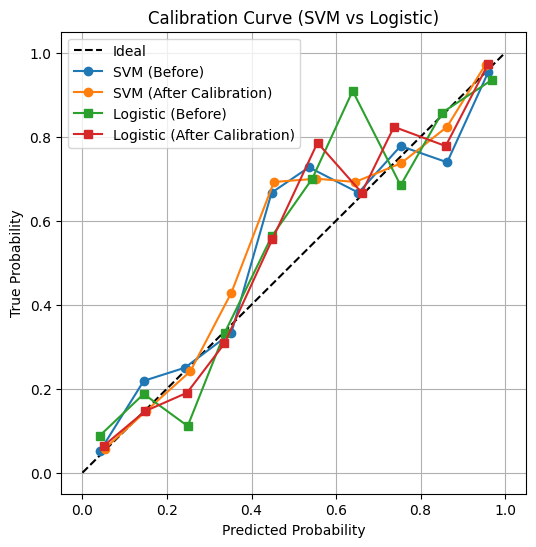

In [17]:
import matplotlib.pyplot as plt
from sklearn.calibration import calibration_curve, CalibratedClassifierCV
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split

# 1️⃣ Data
X, y = make_classification(n_samples=1000, random_state=42)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# 2️⃣ SVM (kalibrasiyasız)
svm_model = SVC(probability=True)
svm_model.fit(X_train, y_train)

svm_probs = svm_model.predict_proba(X_test)[:, 1]

# 3️⃣ SVM Calibration (sigmoid)
svm_calibrated = CalibratedClassifierCV(svm_model, method="sigmoid", cv=5)
svm_calibrated.fit(X_train, y_train)

svm_probs_cal = svm_calibrated.predict_proba(X_test)[:, 1]

# 🔵 4️⃣ Logistic Regression
log_model = LogisticRegression()
log_model.fit(X_train, y_train)

log_probs = log_model.predict_proba(X_test)[:, 1]

# (istəsən bunu da kalibrasiya edə bilərsən, amma adətən ehtiyac olmur)
log_calibrated = CalibratedClassifierCV(log_model, method="sigmoid", cv=5)
log_calibrated.fit(X_train, y_train)

log_probs_cal = log_calibrated.predict_proba(X_test)[:, 1]

# 5️⃣ Calibration curve
svm_true, svm_pred = calibration_curve(y_test, svm_probs, n_bins=10)
svm_true_cal, svm_pred_cal = calibration_curve(y_test, svm_probs_cal, n_bins=10)

log_true, log_pred = calibration_curve(y_test, log_probs, n_bins=10)
log_true_cal, log_pred_cal = calibration_curve(y_test, log_probs_cal, n_bins=10)

# 6️⃣ Plot
plt.figure(figsize=(6,6))

# ideal xətt
plt.plot([0,1], [0,1], "k--", label="Ideal")

# SVM
plt.plot(svm_pred, svm_true, marker="o", label="SVM (Before)")
plt.plot(svm_pred_cal, svm_true_cal, marker="o", label="SVM (After Calibration)")

# Logistic
plt.plot(log_pred, log_true, marker="s", label="Logistic (Before)")
plt.plot(log_pred_cal, log_true_cal, marker="s", label="Logistic (After Calibration)")

plt.xlabel("Predicted Probability")
plt.ylabel("True Probability")
plt.title("Calibration Curve (SVM vs Logistic)")

plt.legend()
plt.grid()
plt.show()